<small>This repository was made by [Riccardo Campi](https://scholar.google.com/citations?user=JWSoz7EAAAAJ&hl=it), PhD student in AI & DS @ Politecnico di Milano, DEIB, Data Science Lab.</small>
<br><small>Thanks to [UBC Library Research Computing](https://github.com/ubc-library-rc/ml-classification-clustering/) for inspiring this notebook.</small>

### 5.2 Regression

In this section, we will focus on supervised learning, specifically regression, where the goal is to predict a continuous output variable based on input features.
<br>We will use the `california housing dataset`, which contains information about various features of houses in California and their corresponding median house values.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

In [2]:
# California housing dataset is a commonly used dataset in data analysis,
# which contains information about different features of houses in California.
california = pd.read_csv('./datasets/california-housing.csv')

# Print the first few rows of the dataset
california.head() 

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [3]:
# Print information about the dataset
california.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


#### 5.2.1 Visualization

We can use visualizations to understand the relationships between the features and the target variable `median_house_value`.
<br>For example, we can create scatter plots to visualize how latitude and longitude relate to each other and to the price.

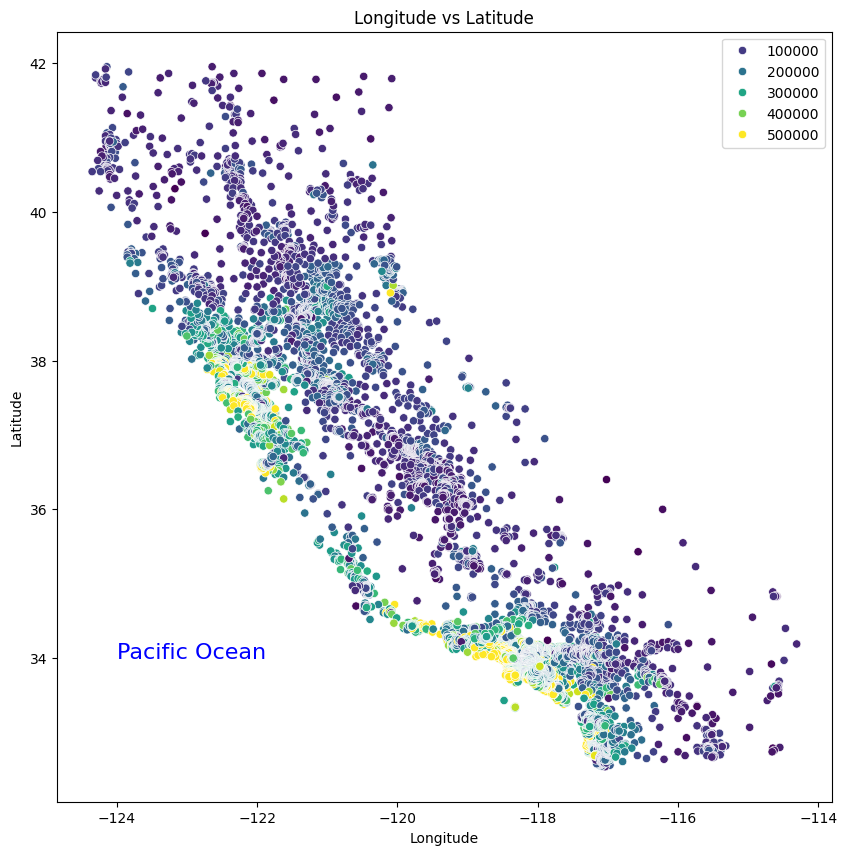

In [4]:
# Create a scatter plot of latitude vs longitude. Color the points by median house value.
plt.figure(figsize=(10, 10))
sns.scatterplot(data=california, x='longitude', y='latitude', hue='median_house_value', palette='viridis')
plt.title('Longitude vs Latitude')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.text(-124, 34, 'Pacific Ocean', fontsize=16, color='blue')
plt.legend()
plt.show()

#### 5.2.2 Train/Test Split

Before training a model, we need to split our dataset into a training set and a test set.
<br>The training set is used to train the model, while the test set is used to evaluate its performance on unseen data.
<br>We can use the `train_test_split` function from the `sklearn.model_selection` module to perform this split.
<br>In this example, we will use 80% of the data for training and 20% for testing, and we will set a random state for reproducibility.

In [5]:
# Store the features and target variable in separate variables
X = california.drop('median_house_value', axis=1)  # Features
y = california['median_house_value']  # Target variable

# Train/test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Drop categorical features
X_train_num = X_train.drop(['ocean_proximity'], axis=1)
X_test_num = X_test.drop(['ocean_proximity'], axis=1)

#### 5.2.3 Missing Values

In real-world datasets, it is common to encounter missing values.
<br>Before training a model, we need to handle these missing values appropriately, as they can affect the performance of the model.
<br>We can use the `SimpleImputer` from the `sklearn.impute` module to fill in missing values with a specified strategy, such as the mean.

In [6]:
from sklearn.impute import SimpleImputer

# Initialize the SimpleImputer with a strategy (e.g., mean)
imputer = SimpleImputer(strategy='mean')

# Fit the imputer on the training data and transform both the training and test data
imputer.fit(X_train_num)
X_train_imputed = imputer.transform(X_train_num)
X_test_imputed = imputer.transform(X_test_num)

#### 5.2.4 Feature Selection

Feature selection is the process of selecting a subset of relevant features for use in model construction.
<br>It can help improve the performance of the model by reducing overfitting, improving accuracy, and reducing training time.
<br>In this example, we will reduce the number of features to location features (`latitude` and `longitude`).

In [7]:
# Keep only the first two features
X_train_selection = X_train_imputed[:, :2]
X_test_selection = X_test_imputed[:, :2]

#### 5.2.5 Model Training

After splitting the data, we can train a regression model using the training set.
<br>For example, we can use a `Linear Regression` model from the `sklearn.linear_model` module to train our model on the training data.

In [8]:
from sklearn import linear_model

# Create linear regression object
LR = linear_model.LinearRegression()

# Train the model using the training sets
LR.fit(X=X_train_selection, y=y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


#### 5.2.6 Model Evaluation

After training the model, we need to evaluate its performance on the test set.
<br>We can use various metrics such as mean squared error (MSE) and R-squared (R²) to assess how well the model is performing:
- **Mean Squared Error (MSE)**: The average of the squared differences between the predicted and actual values. A lower MSE indicates better performance.
- **R-squared (R²)**: The proportion of the variance in the dependent variable that is predictable from the independent variables. An R² value closer to 1 indicates better performance.

In [9]:
from sklearn.metrics import mean_squared_error, r2_score

# Make predictions using the testing set
y_pred = LR.predict(X_test_selection)

# The mean squared error
print("Mean squared error: %.2f" % mean_squared_error(y_test, y_pred))
# The coefficient of determination: 1 is perfect prediction
print("Coefficient of determination: %.2f" % r2_score(y_test, y_pred))

Mean squared error: 9788435787.71
Coefficient of determination: 0.25


> The MSE and R² suggests that the location features alone may not be sufficient to capture the complexity of the housing market, and additional features or a more complex model may be needed to improve performance.

#### 5.2.7 Model Training and Evaluation with All Features

After training and evaluating the model with the selected features, we can also train and evaluate a model using all the features in the dataset.
<br>This allows us to compare the performance of the model with feature selection against the model without feature selection, and to understand the impact of feature selection on the model's performance.

In [10]:
from sklearn import linear_model

# Create linear regression object
LR = linear_model.LinearRegression()

# Train the model using the training sets
LR.fit(X=X_train_imputed, y=y_train)

# Make predictions using the testing set
y_pred_all = LR.predict(X_test_imputed)

# The mean squared error
print("Mean squared error: %.2f" % mean_squared_error(y_test, y_pred_all))
# The coefficient of determination: 1 is perfect prediction
print("Coefficient of determination: %.2f" % r2_score(y_test, y_pred_all))

Mean squared error: 5052955174.60
Coefficient of determination: 0.61


#### 5.2.8 Regression on a Different Dataset

After evaluating the model on the `california housing dataset`, we can try training and evaluating a regression model on a different dataset.
<br>A much simpler dataset is the `students dataset`, which includes information on how many hours students studied, with the second column representing their corresponding exam grades.

In [11]:
# Students dataset is a commonly used dataset in data analysis,
# which contains information about students and their study time, grades, and other features.
students = pd.read_csv('./datasets/students.csv')

# Print the first few rows of the dataset
students.head() 

,studied_hours,exam_grades
0,32.502345,31.707006
1,53.426804,68.777596
2,61.530358,62.562382
3,47.475640,71.546632
4,59.813208,87.230925


In [12]:
# Print information about the dataset
students.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   studied_hours  100 non-null    float64
 1   exam_grades    100 non-null    float64
dtypes: float64(2)
memory usage: 1.7 KB


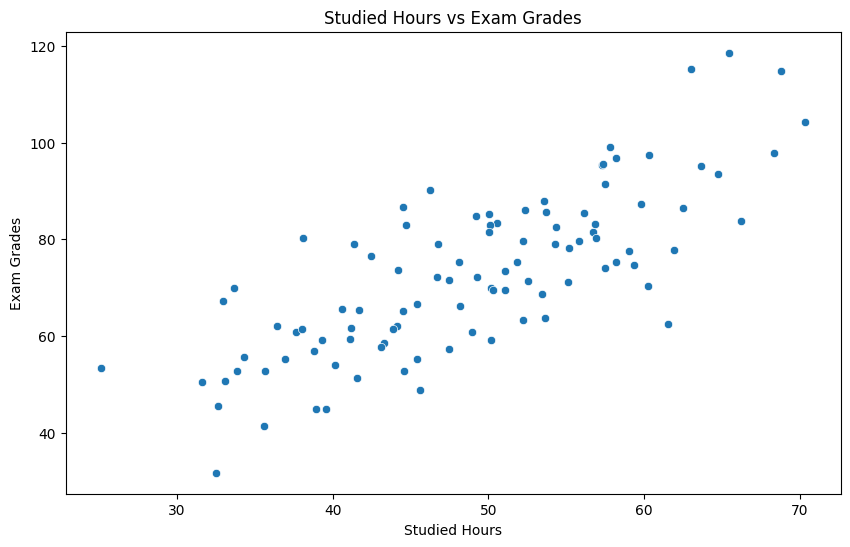

In [13]:
# Plot the relationship between studied hours and exam grades using a scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=students, x='studied_hours', y='exam_grades')
plt.title('Studied Hours vs Exam Grades')
plt.xlabel('Studied Hours')
plt.ylabel('Exam Grades')
plt.show()

In [14]:
# Store the features and target variable in separate variables
X_stud = students.drop('exam_grades', axis=1)  # Features
y_stud = students['exam_grades']  # Target variable

# Train/test split
X_train_stud, X_test_stud, y_train_stud, y_test_stud = train_test_split(X_stud, y_stud, test_size=0.2, random_state=42)

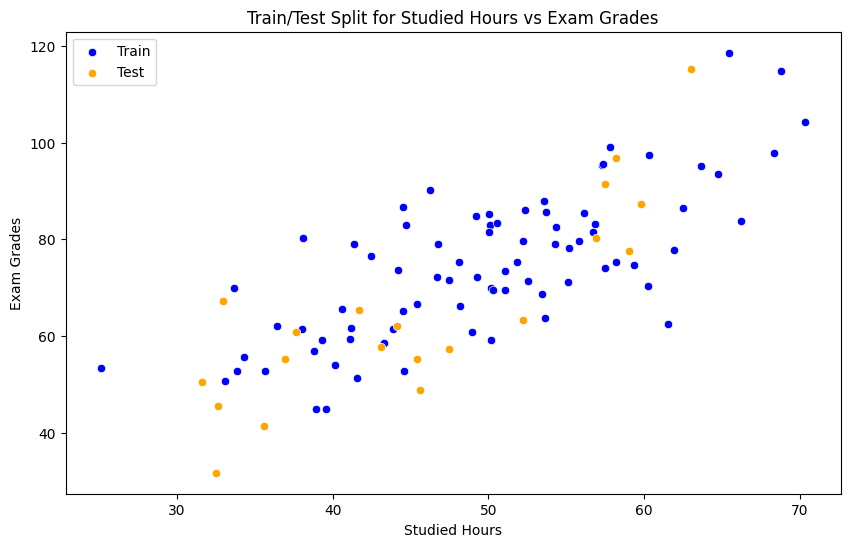

In [15]:
# Plot the train/test split for studied hours and exam grades
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_train_stud['studied_hours'], y=y_train_stud, label='Train', color='blue')
sns.scatterplot(x=X_test_stud['studied_hours'], y=y_test_stud, label='Test', color='orange')
plt.title('Train/Test Split for Studied Hours vs Exam Grades')
plt.xlabel('Studied Hours')
plt.ylabel('Exam Grades')
plt.legend()
plt.show()

In [16]:
from sklearn import linear_model

# Create linear regression object
LR = linear_model.LinearRegression()

# Train the model using the training sets
LR.fit(X=X_train_stud, y=y_train_stud)

# Make predictions using the testing set
y_pred_stud = LR.predict(X_test_stud)

# The mean squared error
print("Mean squared error: %.2f" % mean_squared_error(y_test_stud, y_pred_stud))
# The coefficient of determination: 1 is perfect prediction
print("Coefficient of determination: %.2f" % r2_score(y_test_stud, y_pred_stud))

Mean squared error: 153.21
Coefficient of determination: 0.62


Coefficients: 
 [1.19463787]
Intercept: 
 15.07636055026471


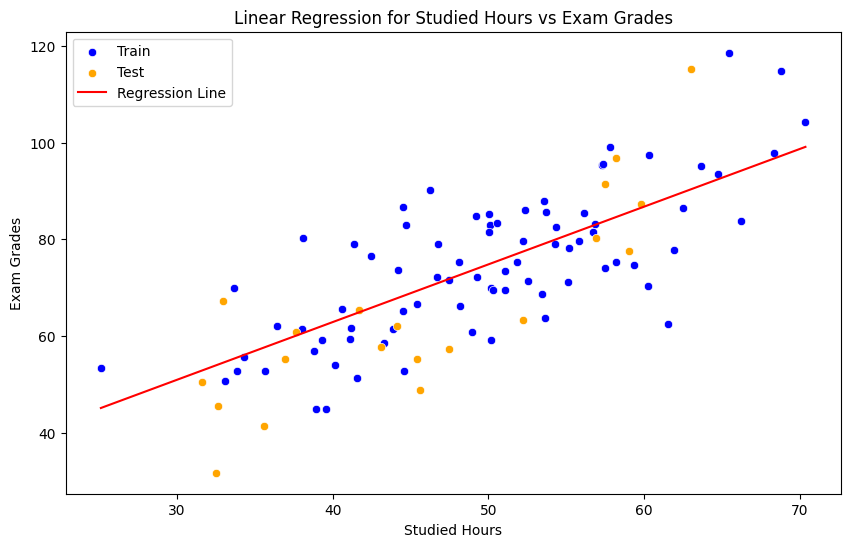

In [17]:
# The coefficients
print("Coefficients: \n", LR.coef_)
# The intercept
print("Intercept: \n", LR.intercept_)

# Plot the regression line computed using coefficients and intercept for studied hours vs exam grades with train/test split highlighted
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_train_stud['studied_hours'], y=y_train_stud, label='Train', color='blue')
sns.scatterplot(x=X_test_stud['studied_hours'], y=y_test_stud, label='Test', color='orange')
# Compute the regression line
x_line = np.linspace(X_stud['studied_hours'].min(), X_stud['studied_hours'].max(), 100)
y_line = LR.intercept_ + LR.coef_[0] * x_line
plt.plot(x_line, y_line, color='red', label='Regression Line')
plt.title('Linear Regression for Studied Hours vs Exam Grades')
plt.xlabel('Studied Hours')
plt.ylabel('Exam Grades')
plt.legend()
plt.show()

#### 5.2.9 Polynomial Regression

Polynomial regression is a type of regression analysis in which the relationship between the independent variable and the dependent variable is modeled as an nth degree polynomial.
<br>It can capture non-linear relationships between the features and the target variable, which may not be adequately captured by a linear regression model.

In this example, we can use polynomial regression on the `AutoMPG Dataset`, which contains information about various features of cars and their corresponding miles per gallon (MPG) values.
<br>We can fit a polynomial regression model on the `MPG` values (input features) using the `horsepower` as the independent variable (output feature), and visualize the resulting polynomial curve along with the original data points.

In [18]:
# Load the AutoMPG dataset
auto_mpg = pd.read_csv('./datasets/auto-mpg.csv')

# Print the first few rows of the dataset
auto_mpg.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [19]:
# Drop rows with missing values in horsepower or mpg
auto_mpg = auto_mpg.replace('?', np.nan)
auto_mpg_clean = auto_mpg.dropna(subset=['horsepower', 'mpg'])

# The input variable is the miles per gallon (mpg) and the output variable is the horsepower
X_mpg = auto_mpg_clean[['horsepower']]  # Input feature
y_mpg = auto_mpg_clean['mpg']  # Target variable

# Transform to numpy arrays
X_mpg = X_mpg.values.astype(float)
y_mpg = y_mpg.values.astype(float)

# Train/test split
X_train_mpg, X_test_mpg, y_train_mpg, y_test_mpg = train_test_split(X_mpg, y_mpg, test_size=0.2, random_state=42)

In [20]:
from sklearn.preprocessing import PolynomialFeatures

# Create polynomial regression object
polynomial_features = PolynomialFeatures(degree=2, include_bias=False)

# Train the model using the training sets
X_poly = polynomial_features.fit_transform(X_train_mpg)

# Create and fit the linear regression model
PL = linear_model.LinearRegression()
PL.fit(X_poly, y_train_mpg)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


> By using `PolynomialFeatures`, we are creating new features that are polynomial combinations of the original features.
<br>The `LinearRegression` model is then used to fit these new polynomial features to the target variable, allowing us to capture non-linear relationships in the data while still using a linear model for fitting.

In [21]:
# Make predictions using the testing set
X_test_poly = polynomial_features.fit_transform(X_test_mpg)
PL_predicted = PL.predict(X_test_poly)

# The mean squared error
print("Mean squared error: %.2f" % mean_squared_error(y_test_mpg, PL_predicted))
# The coefficient of determination: 1 is perfect prediction
print("Coefficient of determination: %.2f" % r2_score(y_test_mpg, PL_predicted))

Mean squared error: 18.42
Coefficient of determination: 0.64


In [22]:
# Make predictions using the testing set
X_test_poly = polynomial_features.fit_transform(X_test_mpg)
PL_predicted = PL.predict(X_test_poly)

# The mean squared error
print("Mean squared error: %.2f" % mean_squared_error(y_test_mpg, PL_predicted))
# The coefficient of determination: 1 is perfect prediction
print("Coefficient of determination: %.2f" % r2_score(y_test_mpg, PL_predicted))

Mean squared error: 18.42
Coefficient of determination: 0.64


Coefficients: 
 [-0.48445839  0.0012949 ]
Intercept: 
 58.212944359180014


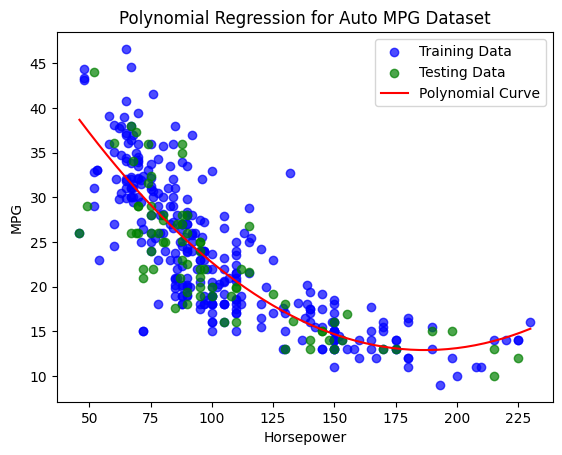

In [23]:
# The coefficients
print("Coefficients: \n", PL.coef_)
# The intercept
print("Intercept: \n", PL.intercept_)

# Visualizing the regression line
plt.scatter(X_train_mpg[:, 0], y_train_mpg, label='Training Data', color='b', alpha=0.7)
plt.scatter(X_test_mpg[:, 0], y_test_mpg, label='Testing Data', color='g', alpha=0.7)
X_curve = np.linspace(X_mpg.min(), X_mpg.max()).reshape(-1, 1)
X_curve_poly = polynomial_features.transform(X_curve)
y_curve = PL.predict(X_curve_poly)
plt.plot(X_curve, y_curve, color='red', label='Polynomial Curve')
plt.title('Polynomial Regression for Auto MPG Dataset')
plt.xlabel('Horsepower')
plt.ylabel('MPG')
plt.legend(loc="best")
plt.show()